In [2]:
from google.colab import files
uploaded = files.upload()  #Select the vgg_model.py and best_model.pth of VGG files here.

Saving best_model.pth to best_model.pth
Saving vgg_model.py to vgg_model.py


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 491kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.53MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.35MB/s]


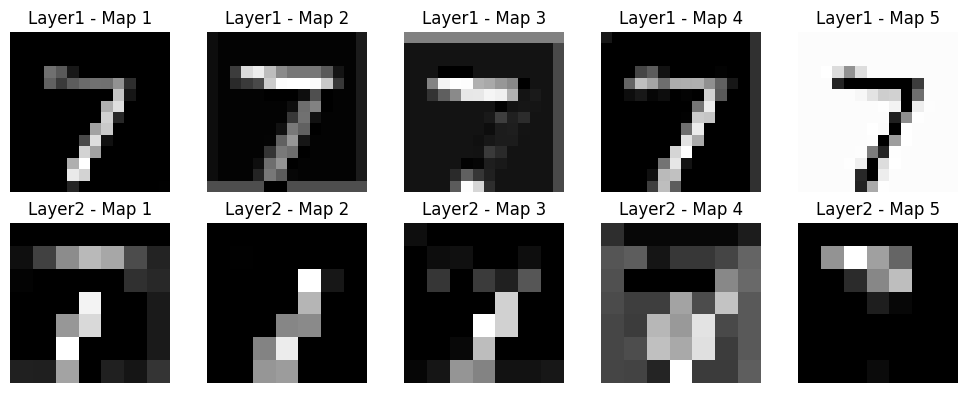

In [4]:
import torch
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from vgg_model import VGGModel

# Load model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VGGModel().to(device)
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()

# Load one sample from test set
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
test_dataset = datasets.MNIST("../data", train=False, download=True, transform=transform)
sample_img, _ = test_dataset[0]
sample_img = sample_img.unsqueeze(0).to(device)

# Get feature maps
with torch.no_grad():
    layer1, layer2 = model.visualize(sample_img)

# Convert to CPU numpy for visualization
layer1 = layer1.squeeze(0).cpu().numpy()
layer2 = layer2.squeeze(0).cpu().numpy()

# Plot few feature maps from each layer
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i in range(5):
    axes[0, i].imshow(layer1[i], cmap="gray")
    axes[0, i].set_title(f"Layer1 - Map {i+1}")
    axes[0, i].axis("off")
    axes[1, i].imshow(layer2[i], cmap="gray")
    axes[1, i].set_title(f"Layer2 - Map {i+1}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.savefig("vgg_feature_maps.png")
plt.show()


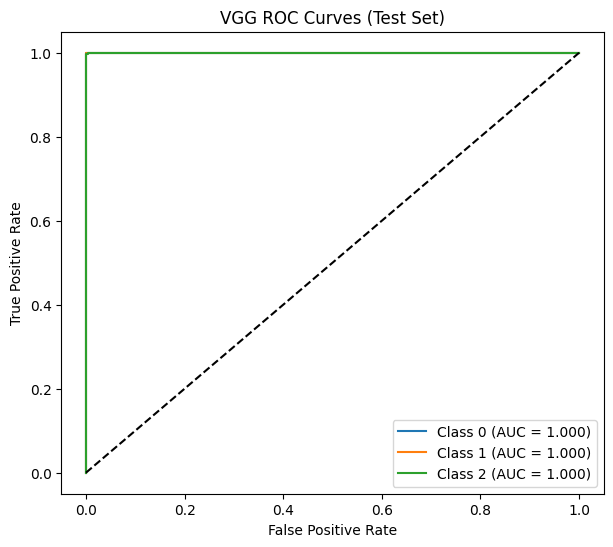

In [5]:
import torch.nn.functional as F
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

model.eval()

# Load test set
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
test_dataset = datasets.MNIST("../data", train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)

# Collect predictions
all_labels, all_probs = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = F.softmax(outputs, dim=1).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(labels.numpy())

all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)
y_test_bin = label_binarize(all_labels, classes=np.arange(10))

# Compute ROC curve for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(10):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(7, 6))
for i in range(3):  # Only a few classes at the beginning for clarity
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.3f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("VGG ROC Curves (Test Set)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.savefig("vgg_roc_curve.png")
plt.show()
